In [ ]:
import pandas as pd
import taxopy
def GetKingdomFromTaxID(taxid):
    try:
        return taxopy.Taxon(int(taxid), taxdb).rank_name_dictionary.get("superkingdom")
    except:
        return "Non-existent"

In [ ]:
reads_stats = pd.read_csv("/home/pedro/aesop/aesop-pipeline/Results/bsb_test/stats/filtered-reads-stats.tsv", sep="\t")
reads_stats['file'] = reads_stats.file.str.replace("_human_R[12].fastq.gz", "", regex=True)
TotalReadsDict = reads_stats.groupby('file')['num_seqs'].sum().to_dict()

In [ ]:
RpipPathogens = pd.read_csv("/home/pedro/aesop/github/aesop_metagenomics_read_length/data/czid_rpip_vsp_pathogens_20240625.csv", sep=",")
RpipPathogens.rename(columns = {"tax_id":"taxonomy_id"}, inplace=True)
BrakenOriginalFile = pd.read_csv("/home/pedro/aesop/aesop-pipeline/Results/bsb_test/abundance/braken-abund.tsv", sep="\t")

In [ ]:
BrakenOriginalFile = BrakenOriginalFile.merge(
    RpipPathogens[["taxonomy_id", "organism", "realm"]],
    on = "taxonomy_id",
    how = "left",
)

In [ ]:
for sample in TotalReadsDict.keys():
    BrakenOriginalFile[f"{sample}.ntrpm"] = BrakenOriginalFile[f"{sample}.braken_num"].apply(lambda x:(x/1_000_000) * TotalReadsDict[sample]).round().astype(int)

In [ ]:
# taxdb = taxopy.TaxDb(
#     nodes_dmp="/home/pedro/aesop/pipeline/databases/taxonomy/taxdump_20250211/nodes.dmp",
#     names_dmp="/home/pedro/aesop/pipeline/databases/taxonomy/taxdump_20250211/names.dmp"
# )
# BrakenOriginalFile["kingdom"] = BrakenOriginalFile.taxonomy_id.apply(GetKingdomFromTaxID)

In [ ]:
ColumnsToKeep = list(BrakenOriginalFile.columns.str.contains(".ntrpm"))
ColumnsToKeep = list(BrakenOriginalFile.columns[ColumnsToKeep]) + ["name", "taxonomy_id", "realm"]

BrakenOriginalFile = BrakenOriginalFile.loc[
    BrakenOriginalFile.realm.isin(["bacteria","eukaryota","viruses"]),
    ColumnsToKeep
    ]
BrakenOriginalFile = BrakenOriginalFile.melt(
    id_vars=["name", "taxonomy_id", "realm"],
    var_name="sample",
    value_name="braken_ntrpm"
)
BrakenOriginalFile

In [ ]:
viruses =   (BrakenOriginalFile.realm == "viruses") & (BrakenOriginalFile.braken_ntrpm >= 1)
bacteria =  (BrakenOriginalFile.realm == "bacteria") & (BrakenOriginalFile.braken_ntrpm >= 10)
eukaryota = (BrakenOriginalFile.realm == "eukaryota") & (BrakenOriginalFile.braken_ntrpm >= 200)
BrakenOriginalFile = BrakenOriginalFile.loc[viruses | bacteria | eukaryota]
BrakenOriginalFile

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

In [ ]:
BackGroud = BrakenOriginalFile.loc[BrakenOriginalFile["sample"].str.contains("MOCK")]
BackGroud = BackGroud.pivot_table(
    index = ["name", "taxonomy_id", "realm"],
    columns = "sample",
    values = "braken_ntrpm",
).reset_index().fillna(0)

BackGroud['mean'] = BackGroud.iloc[:,BackGroud.columns.str.contains("MOCK")].mean(axis=1)
BackGroud['std'] =  BackGroud.iloc[:,BackGroud.columns.str.contains("MOCK")].std(axis=1)
BackGroudMap = BackGroud.set_index('taxonomy_id').to_dict(orient='index')

Samples = BrakenOriginalFile.loc[~BrakenOriginalFile["sample"].str.contains("MOCK")]
Samples['backgroud.mean'] = Samples.taxonomy_id.apply(lambda x: BackGroudMap.get(x, {}).get('mean', 0))
Samples['backgroud.std'] =  Samples.taxonomy_id.apply(lambda x: BackGroudMap.get(x, {}).get('std', 0.0001))
Samples['zscore'] = Samples.apply(
    lambda row: (row['braken_ntrpm'] - row['backgroud.mean']) / row['backgroud.std'],
    axis = 1
)

Virus = Samples[(Samples.realm == "viruses") & (Samples.zscore > 1)]
Bacteria = Samples[(Samples.realm == "bacteria") & (Samples.zscore > 1)]
Eucaria = Samples[(Samples.realm == "eukaryota") & (Samples.zscore > 1)]

Virus = Virus.pivot_table(
    index="name",
    columns="sample",
    values="braken_ntrpm",
    fill_value=0
)
Bacteria = Bacteria.pivot_table(
    index="name",
    columns="sample",
    values="braken_ntrpm",
    fill_value=0
)
Eucaria = Eucaria.pivot_table(
    index="name",
    columns="sample",
    values="braken_ntrpm",
    fill_value=0
)

color_breaks = [0, 1, 5, 25, 100, 500, 1000, 5000, 10000, 50000, 220000, 450000]
heat_colors = [
    "#CCCCCC",  # substituto de grey80
    "#FFFFCC", "#FFEFA5", "#FEDC7F", "#FEBF5B",
    "#FD9D43", "#FC7034", "#F23D26",
    "#D91620", "#B40325", "#800026"
]

cmap = ListedColormap(heat_colors)
norm = BoundaryNorm(color_breaks, ncolors=len(heat_colors), clip=False)

sns.heatmap(
    data=Virus,
    cmap=cmap,
    norm=norm,
    cbar_kws={"label": "nt_rpm"},
)
plt.title("Viral Samples")
plt.tight_layout()
plt.savefig("heatmap_viruses.png", dpi=300, bbox_inches='tight')

sns.heatmap(
    data=Bacteria,
    cmap=cmap,
    norm=norm,
    cbar_kws={"label": "nt_rpm"},
)
plt.title("Bacterial Samples")   
plt.tight_layout()
plt.savefig("heatmap_bacteria.png", dpi=300, bbox_inches='tight')


In [ ]:

sns.heatmap(
    data=Eucaria,
    cmap=cmap,
    norm=norm,
    cbar_kws={"label": "nt_rpm"},
)   
plt.title("Eukaryotic Samples")
plt.tight_layout()
plt.savefig("heatmap_Eucaria.png", dpi=300, bbox_inches='tight')

In [ ]:
color_breaks = [0, 1, 5, 25, 100, 500, 1000, 5000, 10000, 50000, 220000, 450000]
heat_colors = [
    "#CCCCCC",  # substituto de grey80
    "#FFFFCC", "#FFEFA5", "#FEDC7F", "#FEBF5B",
    "#FD9D43", "#FC7034", "#F23D26",
    "#D91620", "#B40325", "#800026"
]

cmap = ListedColormap(heat_colors)
norm = BoundaryNorm(color_breaks, ncolors=len(heat_colors), clip=False)

# Plotando o heatmap com as configurações personalizadas
sns.heatmap(
    data=Virus,
    cmap=cmap,
    norm=norm,
    cbar_kws={"label": "nt_rpm"},
    # linecolor='black',
    # linewidths=0.5
)

plt.tight_layout()
plt.show()

In [ ]:
sns.heatmap(
    data=Bacteria,
    cmap=cmap,
    norm=norm,
    cbar_kws={"label": "nt_rpm"},
)

plt.tight_layout()
plt.show()

In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [94]:
REDcapMetadata = pd.read_csv("AESOP_DATA_2025-06-23_1716.csv")
REDcapMetadata = REDcapMetadata.loc[REDcapMetadata.id_run_enr == "LACENDF_AESOP-C2_RNAPENR_LIBRARY20250129"]
REDcapMetadata.set_index('id_pool', inplace=True)

In [95]:
Symptoms = [
    'febre',
    'tosse',
    'congestao_nasal',
    'coriza',
    'dispneia',
    'odinofagia',
    'cefaleia', 
    'otalgia', 
    'astenia', 
    'mialgia',
    'blenoftalmia', 
    'calafrios', 
    'disgeusia', 
    'vomito', 
    'nausea',
    'dor_toracica', 
    'gastralgia', 
    'abdominalgia', 
    'diarreia', 
    'hipertensao',
    'hipoxia', 
    'enurese', 
    'sonolencia', 
    'artralgia', 
    'conjuntivite'
]

VirusesPCR = [
    'flua_pcr', 'flua_cq',
    'flub_pcr', 'flub_cq', 
    'sars2_pcr', 'sars2_cq', 
    'rinovirus_pcr','rinovirus_cq', 
    'adenovirus_pcr', 'adenovirus_cq',
    'metapneumovirus_pcr', 'metapneumovirus_cq', 
    'rsv_pcr', 'rsv_cq'
]
VirusesCQ = [
    'flua_cq',
    'flub_pcr', 'flub_cq', 
    'sars2_pcr', 'sars2_cq', 
    'rinovirus_pcr',
    'rinovirus_cq', 
    'adenovirus_pcr', 'adenovirus_cq',
    'metapneumovirus_pcr', 'metapneumovirus_cq', 
    'rsv_pcr', 'rsv_cq'
]

In [96]:
REDcapSymptoms = REDcapMetadata[Symptoms]

In [97]:
REDcapPCR_Viruses = REDcapMetadata[VirusesPCR]
REDcapPCR_Viruses = REDcapPCR_Viruses.apply(pd.to_numeric)
# REDcapPCR_Viruses.fillna(99, inplace=True)
REDcapPCR_Viruses = REDcapPCR_Viruses[REDcapPCR_Viruses != 99].dropna(axis=1)


In [98]:
# REDcapPCR_Viruses = REDcapMetadata[VirusesCQ]
# REDcapPCR_Viruses

In [99]:
REdCAP_SymtomsANDVirus = pd.concat([REDcapSymptoms,REDcapPCR_Viruses], axis = 1).T

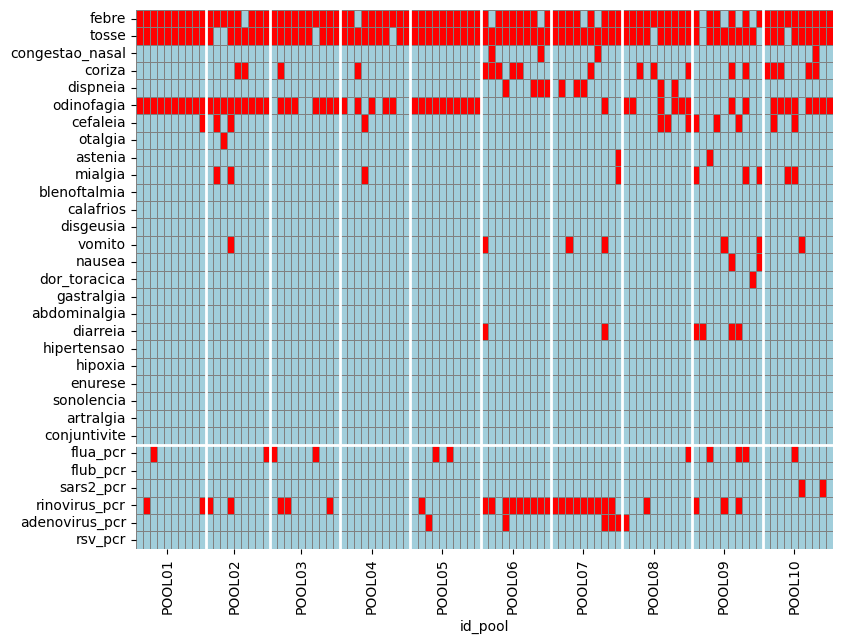

In [100]:
cmap = ListedColormap(["#A1CEDB", "red"])
plt.figure(figsize=(9,7))
ax = sns.heatmap(
    REdCAP_SymtomsANDVirus,
    cmap=cmap, 
    cbar=False,
    linecolor='grey',
    linewidths=0.6
)

cols = REdCAP_SymtomsANDVirus.columns
unique_cols = cols.unique()
tick_positions = []

for u in unique_cols:
    idx = [i for i, c in enumerate(cols) if c == u]
    center = (min(idx) + max(idx)) / 2
    tick_positions.append(center)

# --- aplicar ticks no centro dos grupos ---
ax.set_xticks(tick_positions)
ax.set_xticklabels(unique_cols, rotation=90)


for u in unique_cols[1:]:  
    first_idx = [i for i, c in enumerate(cols) if c == u][0]
    ax.axvline(first_idx, color="white", linewidth=2)

# sua linha horizontal
plt.axhline(y=len(Symptoms), color='white', linewidth=2)


# divisions = [len(Symptoms), len(Symptoms)+len(VirusesSpecies)]
# for div in divisions:
#     plt.axhline(y=div, color='black', linewidth=2)
#     plt.axvline(x=div, color='black', linewidth=2)


In [101]:
pd.concat([REDcapSymptoms,REDcapPCR_Viruses], axis = 1).T

id_pool,POOL01,POOL01,POOL01,POOL01,POOL01,POOL01,POOL01,POOL01,POOL01,POOL01,...,POOL10,POOL10,POOL10,POOL10,POOL10,POOL10,POOL10,POOL10,POOL10,POOL10
febre,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
tosse,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
congestao_nasal,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
coriza,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
dispneia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
odinofagia,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
cefaleia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
otalgia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
astenia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mialgia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [102]:
REDcapMetadata[["rinovirus_cq","rinovirus_pcr"]].dropna()

,rinovirus_cq,rinovirus_pcr
id_pool,,
POOL01,32.0,1
POOL01,35.0,1
POOL02,31.0,1
POOL02,34.0,1
POOL03,38.0,1
POOL03,32.0,1
POOL03,34.0,1
POOL05,35.0,1
POOL06,37.0,1


In [4]:
from docx import Document
from docx.shared import Inches

In [ ]:
doc = Document()

# Adiciona um título
doc.add_heading('Relatório Interno da Equipe de Bioinformática', level=0)

doc.add_heading('1. Methods', level=1).bolsd = True
doc.add_heading('1.1 Download', level=2).bolsd = True
Methods = doc.add_paragraph()
Methods.add_run("O download das amostras sequenciadas foi realizado no Athos (servidor localizado no CIDACS, disponível para o AESOP) utilizando a ferramenta “bs cli” fornecida pelo Illumina BaseSpace para acessar os dados da plataforma")
Methods.add_run("Os genomas humanos GRCh38 e T2T-CHM13v2.0 foram baixados do servidor FTP diretamente do European Molecular Biology Laboratory - European Bioinformatics Institute (EMBL-EBI) e do National Center for Biotechnology Information (NCBI), respectivamente. Os bancos de dados taxonômicos utilizados são disponibilizados publicamente pelo Langmead Lab da Johns Hopkins University, desenvolvedores do software Kraken2 e Bracken, foi o banco standard plus PFP que contém genomas da base RefSeq do NCBI de archaea, bactéria, vírus, plasmídeos, humano, protozoa, fungi e plantas.")


# doc.add_picture('/home/pedro/aesop/aesop-pipeline/Results/bsb_redcap_test/figures/heatmap_bacteria.png', width=Inches(4))  # define largura em polegadas
# doc.add_picture('/home/pedro/aesop/aesop-pipeline/Results/bsb_redcap_test/figures/redcap_heatmap.png', width=Inches(4))  # define largura em polegadas


# Salva o documento
doc.save('exemplo.docx')

In [ ]:
O download das amostras sequenciadas foi realizado no Athos (servidor localizado no CIDACS, disponível para o AESOP) utilizando a ferramenta “bs cli” fornecida pelo Illumina BaseSpace para acessar os dados da plataforma.

Os genomas humanos GRCh38 e T2T-CHM13v2.0 foram baixados do servidor FTP diretamente do European Molecular Biology Laboratory - European Bioinformatics Institute (EMBL-EBI) e do National Center for Biotechnology Information (NCBI), respectivamente. Os bancos de dados taxonômicos utilizados são disponibilizados publicamente pelo Langmead Lab da Johns Hopkins University, desenvolvedores do software Kraken2 e Bracken, foi o banco standard plus PFP que contém genomas da base RefSeq do NCBI de archaea, bactéria, vírus, plasmídeos, humano, protozoa, fungi e plantas.